In [1]:
# %%
# IMPORT LIBRARIES
import sys
sys.path.insert(0, '..')
import helper_functions
from constants import *

import eelbrain
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy import stats
import numpy as np
from statsmodels.stats.contingency_tables import mcnemar



SUBJECTS = helper_functions.get_subjects()


# Auditory Attention Decoding (AAD) Classifier
Classifying attention by the greatest correlation between predicted and actual signal

In [2]:


def aad_classifier(predictor, attention_att, attention_ign, model_type=MODEL_TYPE.FORWARD, padded=False, trf_dir=SELF_COMPUTED_TRF_DIR, plot=True):
    att_name = helper_functions.get_trf_model_name(predictor, attention_att, model_type, padded)
    ign_name = helper_functions.get_trf_model_name(predictor, attention_ign, model_type, padded)

    results = {}  # subject -> correct (True/False)

    for subject in SUBJECTS:
        att_path = trf_dir / subject / f"{subject}_{att_name}_trf.pickle"
        ign_path = trf_dir / subject / f"{subject}_{ign_name}_trf.pickle"

        if not (att_path.exists() and ign_path.exists()):
            print(f"{subject}: missing files, skipping.")
            continue

        att  = eelbrain.load.unpickle(att_path)
        ign  = eelbrain.load.unpickle(ign_path)
        results[subject] = att.r.mean() > ign.r.mean()

    correct   = sum(results.values())
    total     = len(results)
    incorrect = total - correct
    classifier = correct / total if total > 0 else 0.0

    binom_result = stats.binomtest(correct, total, p=0.5, alternative='greater')
    p_value      = binom_result.pvalue

    print(f"Classification rate ({att_name} vs {ign_name}): {classifier:.2%} ({correct}/{total})")
    print(f"Binomial test: p = {p_value:.4f} {helper_functions.sig_marker(p_value)}")

    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

        # Bar plot
        axes[0].bar(['Correct', 'Incorrect'], [correct, incorrect], color=['steelblue', 'coral'], alpha=0.7)
        axes[0].set_title(f'Classification Outcomes\n{att_name.replace("_", " ").title()} vs {ign_name.replace("_", " ").title()}')
        axes[0].set_ylabel('Count')
        axes[0].axhline(total / 2, color='gray', linestyle='--', label='Chance')
        axes[0].legend()

        # Significance summary
        axes[1].axis('off')
        summary = (
            f"N subjects:     {total}\n"
            f"Correct:        {correct} ({classifier:.2%})\n"
            f"Chance:         {total/2:.0f} (50.00%)\n\n"
            f"Binomial test\n"
            f"p-value:        {p_value:.4f}\n"
            f"Significance:   {helper_functions.sig_marker(p_value)}"
        )
        #axes[1].text(0.1, 0.5, summary, transform=axes[1].transAxes, fontsize=11, verticalalignment='center', fontfamily='monospace')

        plt.suptitle(f'AAD: {model_type.value.title()} Model', fontweight='bold')
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / f'{FUGLSANG}-aad_{att_name}_vs_{ign_name}.pdf')
        plt.show()

    return classifier, p_value, results  # return per-subject results for McNemar


In [3]:
def compare_classifiers(results_a, results_b, label_a, label_b, plot = True):
    """
    Compare two classifiers using McNemar's test.
    results_a, results_b: dicts of subject -> correct (True/False)
    """
    subjects = set(results_a.keys()) & set(results_b.keys())

    # Contingency table counts
    a_correct_b_wrong = sum(results_a[s] and not results_b[s] for s in subjects)
    a_wrong_b_correct = sum(not results_a[s] and results_b[s] for s in subjects)

    table = np.array([
        [sum(results_a[s] and results_b[s]     for s in subjects), a_correct_b_wrong],
        [a_wrong_b_correct,                                         sum(not results_a[s] and not results_b[s] for s in subjects)]
    ])

    result  = mcnemar(table, exact=True)  # exact=True recommended for small n
    p_value = result.pvalue

    if plot:
        print(f"\nMcNemar's test: {label_a} vs {label_b}")
        print(f"  {label_a} correct, {label_b} wrong: {a_correct_b_wrong}")
        print(f"  {label_a} wrong, {label_b} correct: {a_wrong_b_correct}")
        print(f"  p = {p_value:.4f} {helper_functions.sig_marker(p_value)}")

    return p_value

In [4]:
_, _, results_env      = aad_classifier(PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.ATTENDED, ATTENTION_TYPE.IGNORED, plot=False)
_, _, results_onset    = aad_classifier(PREDICTOR_TYPE.ENVELOPE_ONSET,  ATTENTION_TYPE.ATTENDED, ATTENTION_TYPE.IGNORED, plot=False)
_, _, results_backward = aad_classifier(PREDICTOR_TYPE.ENVELOPE,        ATTENTION_TYPE.ATTENDED, ATTENTION_TYPE.IGNORED, model_type=MODEL_TYPE.BACKWARD, plot=False)

compare_classifiers(results_env,   results_onset,    'Envelope',  'Onset')
compare_classifiers(results_env,   results_backward, 'Forward',   'Backward')

Classification rate (forward_attended_envelope vs forward_ignored_envelope): 72.22% (13/18)
Binomial test: p = 0.0481 *
Classification rate (forward_attended_envelope_onset vs forward_ignored_envelope_onset): 83.33% (15/18)
Binomial test: p = 0.0038 **
Classification rate (backward_attended_envelope vs backward_ignored_envelope): 88.89% (16/18)
Binomial test: p = 0.0007 ***

McNemar's test: Envelope vs Onset
  Envelope correct, Onset wrong: 0
  Envelope wrong, Onset correct: 2
  p = 0.5000 n.s.

McNemar's test: Forward vs Backward
  Forward correct, Backward wrong: 1
  Forward wrong, Backward correct: 4
  p = 0.3750 n.s.


np.float64(0.375)

Classification rate (forward_attended_envelope vs forward_ignored_envelope): 72.22% (13/18)
Binomial test: p = 0.0481 *
Classification rate (forward_attended_envelope_onset vs forward_ignored_envelope_onset): 83.33% (15/18)
Binomial test: p = 0.0038 **
Classification rate (forward_attended_envelope+envelope_onset vs forward_ignored_envelope+envelope_onset): 83.33% (15/18)
Binomial test: p = 0.0038 **
Classification rate (backward_attended_envelope vs backward_ignored_envelope): 88.89% (16/18)
Binomial test: p = 0.0007 ***


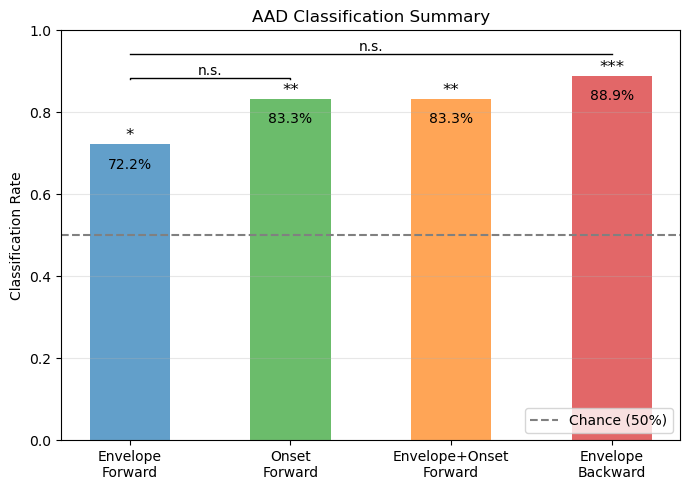

In [5]:
def plot_aad_summary(trf_dir=SELF_COMPUTED_TRF_DIR):
    classifiers = [
        (PREDICTOR_TYPE.ENVELOPE,       MODEL_TYPE.FORWARD,  'Envelope\nForward'),
        (PREDICTOR_TYPE.ENVELOPE_ONSET, MODEL_TYPE.FORWARD,  'Onset\nForward'),
        ([PREDICTOR_TYPE.ENVELOPE, PREDICTOR_TYPE.ENVELOPE_ONSET],       MODEL_TYPE.FORWARD,  'Envelope+Onset\nForward'),        
        (PREDICTOR_TYPE.ENVELOPE,       MODEL_TYPE.BACKWARD, 'Envelope\nBackward'),
    ]

    rates   = []
    p_vals  = []
    results = []

    for predictor, model_type, _ in classifiers:
        rate, p, res = aad_classifier(predictor, ATTENTION_TYPE.ATTENDED, ATTENTION_TYPE.IGNORED, model_type=model_type, trf_dir=trf_dir, plot=False)
        rates.append(rate)
        p_vals.append(p)
        results.append(res)

    comparisons = [
        (0, 3, 'Fwd vs Bwd'),
        (0, 1, 'Env vs Onset'),
    ]

    labels = [c[2] for c in classifiers]
    x      = np.arange(len(labels))
    colors = ['tab:blue', 'tab:green', 'tab:orange', 'tab:red']

    fig, ax = plt.subplots(figsize=(7, 5))

    bars = ax.bar(x, rates, color=colors, alpha=0.7, width=0.5)
    ax.axhline(0.5, color='gray', linestyle='--', label='Chance (50%)')

    # Binomial test markers above each bar
    for i, (rate, p) in enumerate(zip(rates, p_vals)):
        ax.text(i, rate + 0.01, helper_functions.sig_marker(p), ha='center', fontsize=12)
        ax.text(i, rate - 0.06, f"{np.round(rate, 3)*100}%", ha='center', fontsize=10)

    # McNemar comparison lines
    for height_offset, (i, j, _) in enumerate(comparisons):
        y_max = max([rates[i], rates[j]])
        y = y_max + ( y_max / 17)
        helper_functions.add_sig_line(
            ax, i, j, y,
            helper_functions.sig_marker(compare_classifiers(results[i], results[j], labels[i], labels[j], plot=False))
        )

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel('Classification Rate')
    ax.set_title('AAD Classification Summary')
    ax.set_ylim(0, 1)
    ax.legend(loc='lower right')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'{FUGLSANG}_aad_summary.pdf', bbox_inches='tight')
    plt.show()

plot_aad_summary()

Classification rate (forward_attended_envelope vs forward_ignored_envelope): 83.33% (15/18)
Binomial test: p = 0.0038 **
Classification rate (forward_attended_envelope_onset vs forward_ignored_envelope_onset): 83.33% (15/18)
Binomial test: p = 0.0038 **
Classification rate (forward_attended_envelope+envelope_onset vs forward_ignored_envelope+envelope_onset): 83.33% (15/18)
Binomial test: p = 0.0038 **
Classification rate (backward_attended_envelope vs backward_ignored_envelope): 94.44% (17/18)
Binomial test: p = 0.0001 ***
Classification rate (forward_attended_envelope vs forward_ignored_envelope): 72.22% (13/18)
Binomial test: p = 0.0481 *
Classification rate (forward_attended_envelope_onset vs forward_ignored_envelope_onset): 83.33% (15/18)
Binomial test: p = 0.0038 **
Classification rate (forward_attended_envelope+envelope_onset vs forward_ignored_envelope+envelope_onset): 83.33% (15/18)
Binomial test: p = 0.0038 **
Classification rate (backward_attended_envelope vs backward_ignored

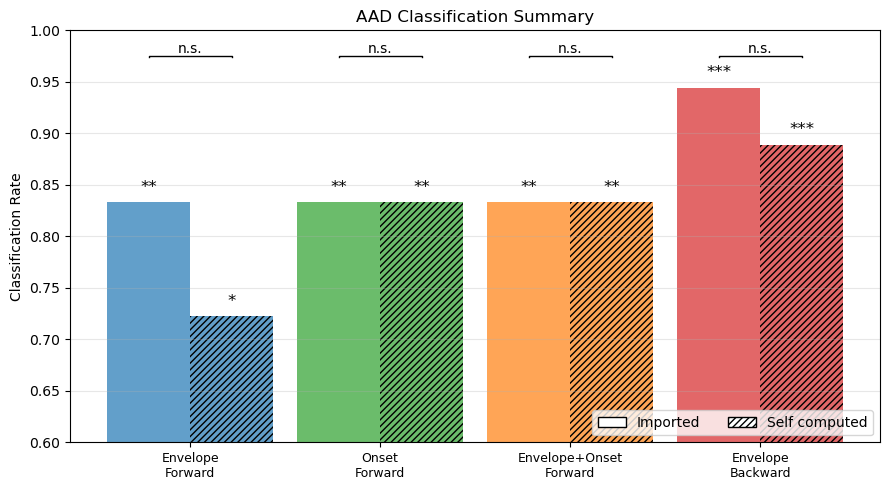

In [7]:
def plot_aad_summary_comparison():
    trf_dirs=[MAT_FILE_TRF_DIR, SELF_COMPUTED_TRF_DIR]
    
    classifiers = [
        (PREDICTOR_TYPE.ENVELOPE,       MODEL_TYPE.FORWARD,  'Envelope\nForward'),
        (PREDICTOR_TYPE.ENVELOPE_ONSET, MODEL_TYPE.FORWARD,  'Onset\nForward'),
        ([PREDICTOR_TYPE.ENVELOPE, PREDICTOR_TYPE.ENVELOPE_ONSET], MODEL_TYPE.FORWARD, 'Envelope+Onset\nForward'),
        (PREDICTOR_TYPE.ENVELOPE,       MODEL_TYPE.BACKWARD, 'Envelope\nBackward'),
    ]

    n_cls  = len(classifiers)
    n_dirs = len(trf_dirs)
    trf_names = ["Imported", "Self computed"]

    # rates[dir_idx][clf_idx], same for p_vals and results
    rates   = np.zeros((n_dirs, n_cls))
    p_vals  = np.zeros((n_dirs, n_cls))
    results = [[None] * n_cls for _ in range(n_dirs)]

    for d, trf_dir in enumerate(trf_dirs):
        for c, (predictor, model_type, _) in enumerate(classifiers):
            rate, p, res = aad_classifier(
                predictor, ATTENTION_TYPE.ATTENDED, ATTENTION_TYPE.IGNORED,
                model_type=model_type, trf_dir=trf_dir, plot=False
            )
            rates[d, c]   = rate
            p_vals[d, c]  = p
            results[d][c] = res

    # Grouped bar layout
    bar_width = 0.35
    gap       = 0.1                          # extra space between classifier groups
    group_w   = n_dirs * bar_width + gap
    x         = np.arange(n_cls) * group_w  # center of each classifier group



    fig, ax = plt.subplots(figsize=(max(9, n_cls * group_w * 1.8), 5))

    clf_colors  = ['tab:blue', 'tab:green', 'tab:orange', 'tab:red']
    dir_hatches = ['', '/////']

    for d in range(n_dirs):
        offsets = (d - (n_dirs - 1) / 2) * bar_width
        x_d     = x + offsets
        bars    = ax.bar(
            x_d, rates[d], width=bar_width,
            color=clf_colors[:n_cls], hatch=dir_hatches[d],
            alpha=0.7, label=trf_names[d]
        )

        # Binomial sig markers
        for i, (rate, p) in enumerate(zip(rates[d], p_vals[d])):
            ax.text(x_d[i], rate + 0.01, helper_functions.sig_marker(p), ha='center', fontsize=12)

    # Cross-dir sig lines per classifier group
    base_y = rates.max() + 0.03
    for c in range(n_cls):
        x_left  = x[c] - bar_width / 2
        x_right = x[c] + bar_width / 2
        p_cross = compare_classifiers(
            results[0][c], results[1][c],
            f"{trf_names[0]} {classifiers[c][2]}", f"{trf_names[1]} {classifiers[c][2]}",
            plot=False
        )
        helper_functions.add_sig_line(ax, x_left, x_right, base_y,
                                      helper_functions.sig_marker(p_cross))

    

    # Dir hatch legend entries
    hatch_handles = [
        Patch(facecolor='white', edgecolor='black', hatch=dir_hatches[d], label=trf_names[d])
        for d in range(n_dirs)
    ]

    ax.legend(
        handles=hatch_handles,
        loc='lower right',
        ncol=2,  # side by side or adjust to taste
    )
    ax.set_xticks(x)
    ax.set_xticklabels([c[2] for c in classifiers], fontsize=9)
    ax.set_ylabel('Classification Rate')
    ax.set_title('AAD Classification Summary')
    ax.set_ylim(0.6, 1)
    #ax.legend(loc='lower right')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'{FUGLSANG}_aad_summary_comparison.pdf', bbox_inches='tight')
    plt.show()
plot_aad_summary_comparison()